## 1. Imports

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import joblib                        

In [14]:
def load_data(path):
    df = pd.read_csv(path)

    # sort so lag features are computed in correct time order per area
    df = df.sort_values(["moh_area", "week"])

    print(f"Shape      : {df.shape}")
    print(f"MOH areas  : {df['moh_area'].nunique()}")
    return df


df = load_data(".\data\Cleaned_Dengue_Data.csv")
df.head()

Shape      : (38575, 15)
MOH areas  : 365


<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Thinura\AppData\Local\Temp\ipykernel_10348\1934010717.py:12: SyntaxWarning: invalid escape sequence '\d'
  df = load_data(".\data\Cleaned_Dengue_Data.csv")


,Province,District,moh_area,week,cases,avg_temperature_2m_mean,avg_temperature_2m_max,avg_precipitation_sum,avg_relative_humidity_2m_mean,temp_range,heat_humidity_index,week_sin,week_cos,moh_area_encoded,cases_log1p
0,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,1,5,-0.174557,-0.747149,0.206094,0.750776,-1.230130,0.767126,0.167360,1.366462,0,1.791759
1,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,2,3,-0.139963,-0.836774,1.692282,0.016894,-1.495016,-0.068804,0.336831,1.335935,0,1.386294
2,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,3,8,-0.285585,-0.611353,-0.674882,0.156910,-0.516977,-0.057190,0.501324,1.285551,0,2.197225
3,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,4,11,0.217073,-0.296306,-0.970167,-1.281188,-0.387930,-1.282769,0.658439,1.216046,0,2.484907
4,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,5,4,-0.095019,-0.385930,0.037708,0.687188,-0.578104,0.780247,0.805885,1.128431,0,1.609438


In [15]:
def engineer_features(df):

    # encode MOH area names as numbers 
    encoder = LabelEncoder()
    df["area_encoded"] = encoder.fit_transform(df["moh_area"])

    # lag features (cases from previous weeks) 
    df["cases_lag1"] = df.groupby("moh_area")["cases"].shift(1)   # 1 week ago
    df["cases_lag2"] = df.groupby("moh_area")["cases"].shift(2)   # 2 weeks ago
    df["cases_lag3"] = df.groupby("moh_area")["cases"].shift(3)   # 3 weeks ago


    # rolling average of the past 4 weeks 
    # Raw hospital data is noisy. A hospital might report zero cases one week due to administrative delays, and double the cases the next week. If the model only looks at last week's raw count, it gets confused by that noise.
    df["cases_roll_mean4"] = (
        df.groupby("moh_area")["cases"]
        .shift(1)
        .transform(lambda x: x.rolling(4, min_periods=1).mean())
    )

    
    # trend is dengue going up or down vs last week
    df["cases_trend"] = df["cases_lag1"] - df["cases_lag2"]

    # previous week weather (lagged to avoid leakage) 
    df["temp_lag1"]     = df.groupby("moh_area")["avg_temperature_2m_mean"].shift(1)
    df["precip_lag1"]   = df.groupby("moh_area")["avg_precipitation_sum"].shift(1)
    df["humidity_lag1"] = df.groupby("moh_area")["avg_relative_humidity_2m_mean"].shift(1)


    # Compresses massive outbreak spikes, massive statistical spikes caused by severe outbreaks into a smoother curve so the algorithm can learn the baseline trends without crashing when it sees zero cases 
    df["cases_log1p"] = np.log1p(df["cases"])

     # clean up missing values and reset Index
    df = df.dropna().reset_index(drop=True)
 
    
    print(f"Shape after feature engineering: {df.shape}")
    return df, encoder


df, encoder = engineer_features(df)
df.head()

Shape after feature engineering: (37480, 24)


,Province,District,moh_area,week,cases,avg_temperature_2m_mean,avg_temperature_2m_max,avg_precipitation_sum,avg_relative_humidity_2m_mean,temp_range,...,cases_log1p,area_encoded,cases_lag1,cases_lag2,cases_lag3,cases_roll_mean4,cases_trend,temp_lag1,precip_lag1,humidity_lag1
0,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,4,11,0.217073,-0.296306,-0.970167,-1.281188,-0.387930,...,2.484907,0,8.0,3.0,5.0,5.333333,5.0,-0.285585,-0.674882,0.156910
1,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,5,4,-0.095019,-0.385930,0.037708,0.687188,-0.578104,...,1.609438,0,11.0,8.0,3.0,6.750000,3.0,0.217073,-0.970167,-1.281188
2,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,6,3,0.419616,-0.231124,-0.945763,-1.229627,-0.781862,...,1.386294,0,4.0,11.0,8.0,6.500000,-7.0,-0.095019,0.037708,0.687188
3,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,7,5,0.574109,-0.138782,-0.623634,-0.419520,-1.046748,...,1.791759,0,3.0,4.0,11.0,6.500000,-1.0,0.419616,-0.945763,-1.229627
4,Eastern Province,Kalmunai RDHS,MOH-Addalachchenai,8,1,0.612400,0.181697,-0.994571,-0.553971,-0.272466,...,0.693147,0,5.0,3.0,4.0,5.750000,2.0,0.574109,-0.623634,-0.419520


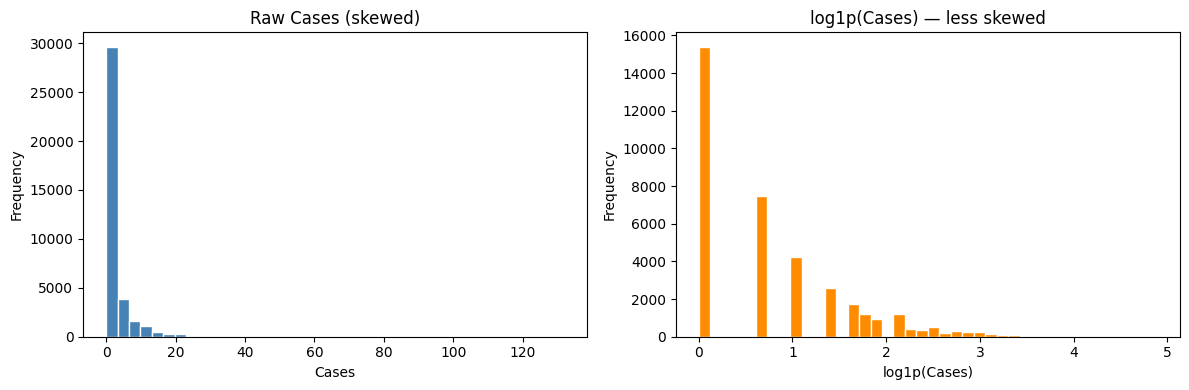

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["cases"], bins=40, color="steelblue", edgecolor="white")
axes[0].set(title="Raw Cases (skewed)", xlabel="Cases", ylabel="Frequency")

axes[1].hist(df["cases_log1p"], bins=40, color="darkorange", edgecolor="white")
axes[1].set(title="log1p(Cases) — less skewed", xlabel="log1p(Cases)", ylabel="Frequency")

plt.tight_layout()
plt.show()

In [17]:
FEATURES = [
    # area identifier
    "area_encoded",

    # current week weather
    "avg_temperature_2m_mean",
    "avg_temperature_2m_max",
    "avg_precipitation_sum",
    "avg_relative_humidity_2m_mean",
    "temp_range",
    "heat_humidity_index",

    # temporal
    "week",
    "week_sin",
    "week_cos",

    # lag & rolling case features
    "cases_lag1",
    "cases_lag2",
    "cases_lag3",
    "cases_roll_mean4",
    "cases_trend",

    # lagged weather
    "temp_lag1",
    "precip_lag1",
    "humidity_lag1",
]

TARGET_RAW = "cases"          # original count — used for evaluation
TARGET_LOG = "cases_log1p"    # log-transformed — used for model training

for f in FEATURES:
    print(f"  {f}")

  area_encoded
  avg_temperature_2m_mean
  avg_temperature_2m_max
  avg_precipitation_sum
  avg_relative_humidity_2m_mean
  temp_range
  heat_humidity_index
  week
  week_sin
  week_cos
  cases_lag1
  cases_lag2
  cases_lag3
  cases_roll_mean4
  cases_trend
  temp_lag1
  precip_lag1
  humidity_lag1


In [18]:
# Time-split 
TRAIN_END = 80   # weeks  1-80  → training
VAL_END   = 93   # weeks 81-93  → validation
                 # weeks 94+   → test

def split_data(df):

    train_df = df[df["week"] <= TRAIN_END].copy()
    val_df   = df[(df["week"] > TRAIN_END) & (df["week"] <= VAL_END)].copy()
    test_df  = df[df["week"] > VAL_END].copy()

    print(f"Train   {len(train_df):,} rows")
    print(f"Val    {len(val_df):,} rows")
    print(f"Test    {len(test_df):,} rows")

    return train_df, val_df, test_df

# catch all results and unpacking them
results = split_data(df)
train_df           = results[0]  
val_df             = results[1]  
test_df            = results[2]  

Train   28,017 rows
Val    4,732 rows
Test    4,731 rows


In [19]:
train_df.to_csv(os.path.join('data', "train.csv"), index=False)
val_df.to_csv(  os.path.join('data', "val.csv"),   index=False)
test_df.to_csv( os.path.join('data', "test.csv"),  index=False)
joblib.dump(encoder, "models/encoder.pkl")

['models/encoder.pkl']